# PRCP-1019: Concrete Strength Prediction Project

---

## Project Objective
* **Task 1**: Prepare a complete data analysis report on the concrete data.
* **Task 2**: Create a machine learning model which can predict the future strength of a concrete mix based on its constituents' composition and age.
* **Reporting**: Provide a comprehensive Model Comparison Report and a Report on Challenges Faced.

In [1]:
# Import Essential library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Load Dataset and Overview

In [2]:
# Load Dataset
df=pd.read_csv('concrete.csv')

In [3]:
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
df.shape

(1030, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [6]:
df.isnull().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(25)

In [8]:
df=df.drop_duplicates().reset_index(drop=True)

In [9]:
df.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.631343,72.043483,55.536318,182.075323,6.033234,974.376816,772.688259,45.856716,35.250378
std,104.344261,86.170807,64.207969,21.339334,5.919967,77.579667,80.340435,63.734692,16.284815
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,190.700000,0.000000,0.000000,166.600000,0.000000,932.000000,724.300000,7.000000,23.520000
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.800000
75%,349.000000,142.500000,118.300000,192.900000,10.000000,1031.000000,822.200000,56.000000,44.870000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


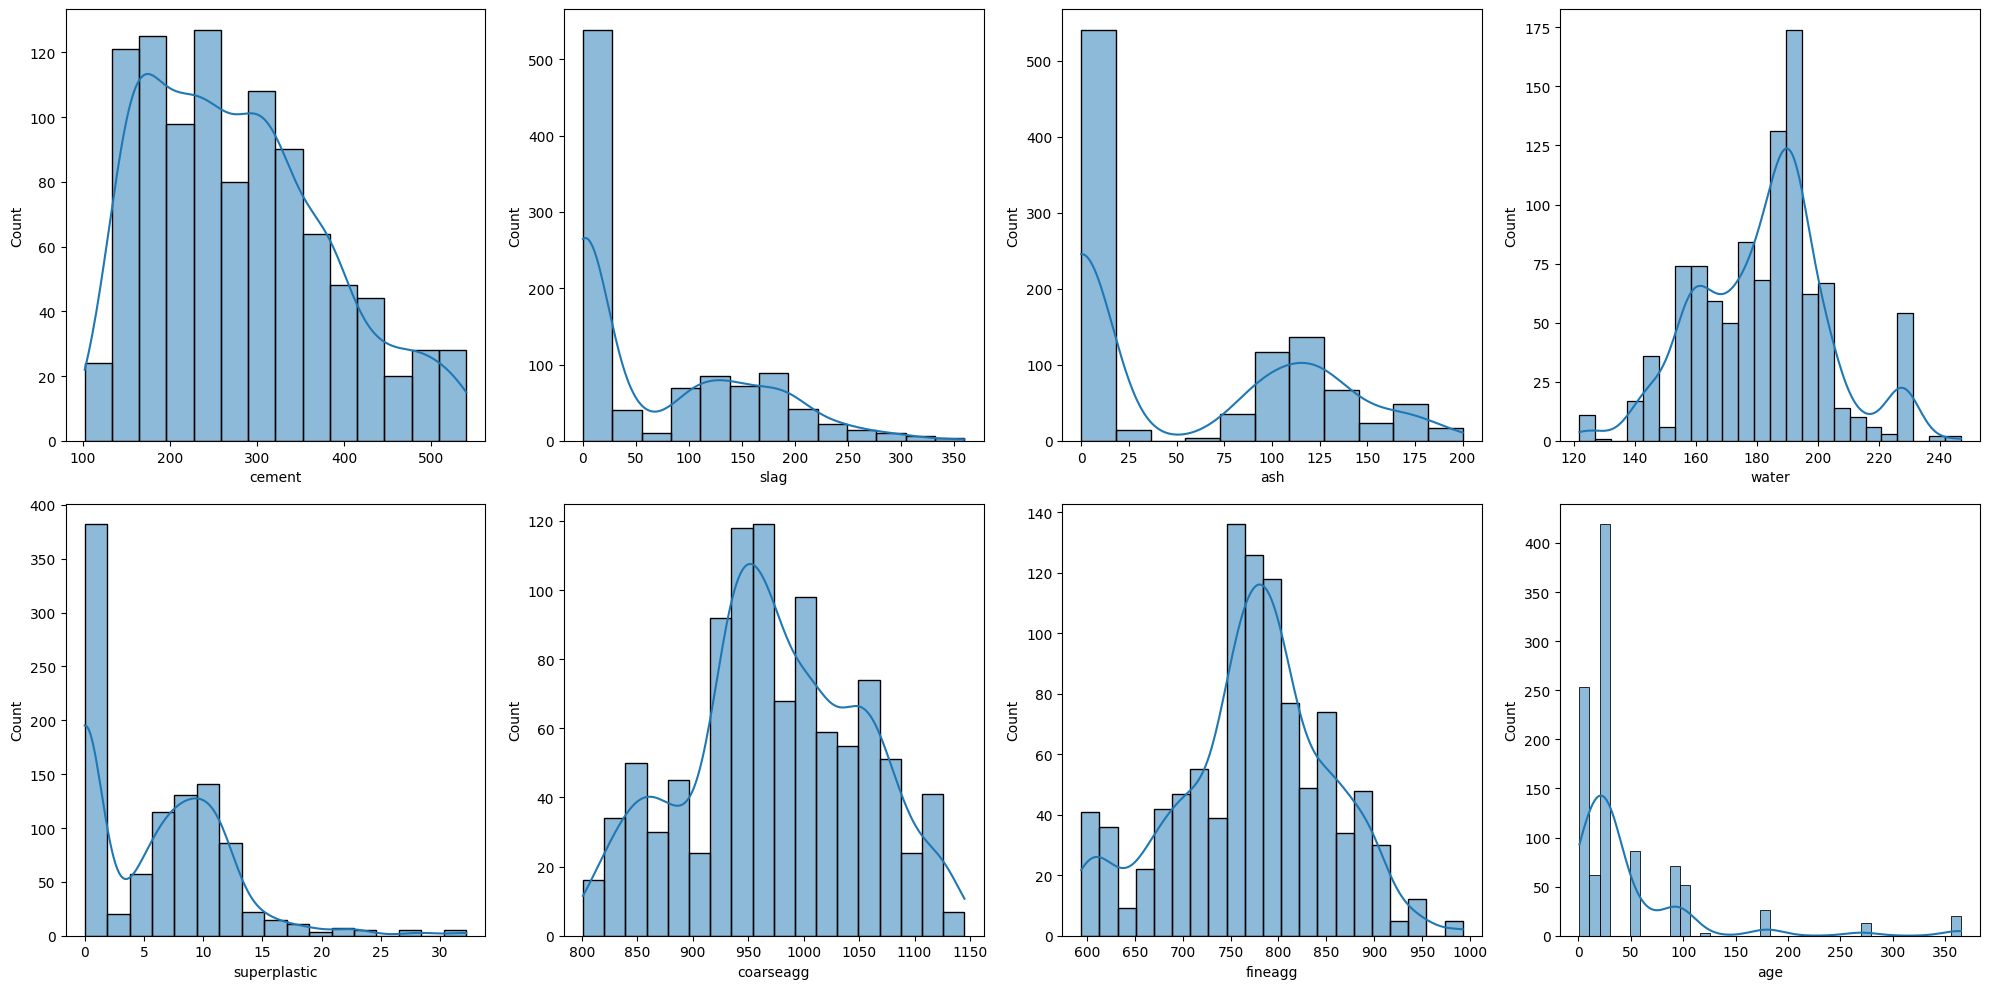

In [10]:
fig, axes = plt.subplots(2,4, figsize=(20,10))
[sns.histplot(df, x=col, kde=True, ax=ax) for col, ax in zip(['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age'], axes.flat)]
plt.tight_layout()
plt.show()    

* **cement:** Most mixes use between 150 and 300 units of cement, with a right-skewed tail showing that very high amounts (over 400) are rarely used.
* **slag:** More than half of the recipes do not include slag at all (large spike at zero). When it is used, amounts typically cluster between 100 and 200 units.
* **ash:** Fly ash is completely omitted in over half the samples. When added, it is mostly used in amounts between 90 and 150 units.
* **water:** Follows a fairly balanced, bell-like spread centered around 180 to 190 units, with noticeable spikes indicating standard recipe ratios.
* **superplastic:** Over a third of the batches do not use superplasticizer at all. When present, it is added in small doses, usually between 5 and 15 units.
* **coarseagg:** Displays a roughly normal (bell-shaped) distribution centered around 950 units, meaning most batches stick close to the average gravel content.
* **fineagg:** Also shows an approximately normal distribution, peaking around 750 to 800 units with very few extreme values on either side.
* **age:** Heavily right-skewed with most tests concentrated at early stages (such as 7, 14, and 28 days), while testing on aged concrete (up to 365 days) is rare.   

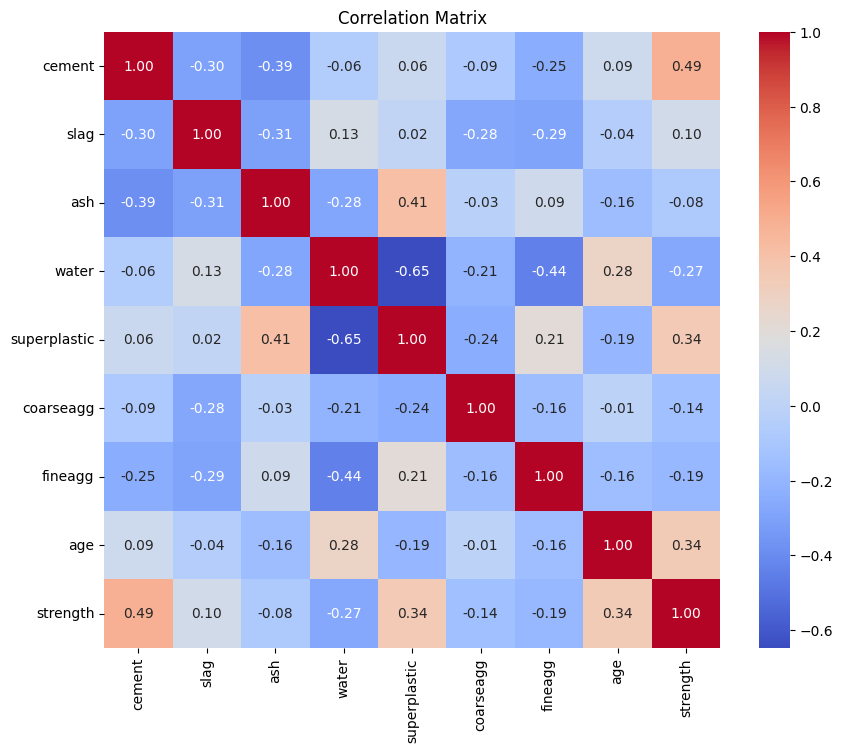

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

* Cement is the strongest positive driver of strength ($+0.49$): Higher cement content correlates most strongly with higher compressive strength, followed equally by curing age ($+0.34$) and superplasticizer ($+0.34$).
* Excess water reduces concrete strength ($-0.27$): Water has the most notable negative correlation with final compressive strength, reflecting standard mix design principles where a higher water-to-binder ratio weakens the cured concrete.
* Superplasticizer and water have a strong inverse relationship ($-0.65$): This is the strongest correlation across the entire dataset, aligning with the real-world function of water-reducing admixtures (superplasticizers allow workability with significantly less water).
* Fly ash acts as a cement substitute ($-0.39$): Ash has a moderate negative correlation with cement, consistent with mix designs where supplementary cementitious materials replace a portion of ordinary Portland cement.
* Low risk of severe multicollinearity: All feature-to-feature correlations stay well below the typical multicollinearity threshold ($\vert{}r\vert{} < 0.70$ or $0.80$), meaning standard regression models (e.g., Linear Regression, Ridge, or tree-based algorithms) can utilize all features without significant collinear distortion.

### Task 1: Data Analysis Report

The concrete dataset was analyzed to understand the data and find useful patterns.

- The dataset contains 8 input variables and 1 target variable.
- Missing values and duplicate records were checked.
- Descriptive statistics were used to understand the data.
- Histograms were used to study data distributions.
- Boxplots were used to identify possible outliers.
- Scatter plots were used to study the relationship between input variables and concrete strength.
- A correlation heatmap was used to understand relationships between variables.

The target variable is Concrete Compressive Strength (MPa).

The analysis shows that concrete strength depends on the concrete ingredients and the age of the concrete. The relationship between the variables is not completely linear, so different machine learning models were tested.

In [12]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [15]:
models={'LR':Pipeline([('scaler',StandardScaler()),('rgr',LinearRegression())]),
        'KNN':Pipeline([('scaler',StandardScaler()),('rgr',KNeighborsRegressor())]),
       'DT':Pipeline([('scaler',StandardScaler()),('rgr',DecisionTreeRegressor())]),
       'RF':Pipeline([('scaler',StandardScaler()),('rgr',RandomForestRegressor())]),
       'GB':Pipeline([('scaler',StandardScaler()),('rgr',GradientBoostingRegressor())]),
       'XGB':Pipeline([('scaler',StandardScaler()),('rgr',XGBRegressor())])}  

In [16]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

results=[]

for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    results.append({'Model':name,
                    'R2':r2_score(y_test,y_pred),
                   'MAE':mean_absolute_error(y_test,y_pred),
                   'MSE':mean_squared_error(y_test,y_pred),
                   'RMSE':np.sqrt(mean_squared_error(y_test,y_pred))})

In [17]:
comparison_df=pd.DataFrame(results).set_index('Model')
print(comparison_df)

             R2       MAE         MSE       RMSE
Model                                           
LR     0.580170  8.895256  125.245648  11.191320
KNN    0.715907  7.139194   84.752015   9.206086
DT     0.876882  3.908881   36.729099   6.060454
RF     0.909165  3.535508   27.098455   5.205618
GB     0.894960  4.123885   31.335992   5.597856
XGB    0.924316  2.930609   22.578285   4.751661


### Model Comparison Report

* **Performance Summary**:

| Model                     | $R^2$ Score |  MAE (MPa) |  MSE (MPa)  | RMSE (MPa) |
| :------------------------ | :---------: | :--------: | :---------: | :--------: |
| Linear Regression (LR)    |    0.58     |   8.89     |   125.24    |   11.19    |
| K-Nearest Neighbors (KNN) |    0.71     |   7.13     |   84.75     |   9.20     |
| Decision Tree (DT)        |    0.87     |   3.93     |   36.98     |   6.08     |
| Random Forest (RF)        |    0.90     |   3.57     |   27.48     |   5.24     |
| Gradient Boosting (GB)    |    0.89     |   4.11     |   31.36     |   5.60     |
| **XGBoost (XGB)**         |  **0.92**   | **2.93**   | **22.57**   | **4.75**   |

Different machine learning models were trained and compared to predict concrete compressive strength.

The models were evaluated using: **R² | MAE | RMSE**

* Higher R² and lower MAE and RMSE indicate better model performance.
* The models were compared based on their test results. The model with the best overall performance was selected as the final model.
* Hyperparameter tuning was also performed to improve the performance of the selected models.

### Final Model

* The final model was selected based on its performance on the test data.
* The selected model is used to predict the compressive strength of new concrete mixtures.

In [18]:
model=XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [19]:
# Hyperparameter grid for Random Forest
param_grid = {'n_estimators': [100, 200],
              'max_depth': [12, 14, 16, 18, 20]}

grid_search = GridSearchCV(estimator=model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='r2',
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_final_pred = best_model.predict(X_test)

print(f'Optimal Hyperparameters: {grid_search.best_params_}')
print(f'Mean CV R2: {grid_search.best_score_:.4f}')
print(f'Final Test R2: {r2_score(y_test, y_final_pred):.4f}')
print(f'Final Test MAE: {mean_absolute_error(y_test, y_final_pred):.2f} MPa')

Optimal Hyperparameters: {'max_depth': 12, 'n_estimators': 200}
Mean CV R2: 0.8749
Final Test R2: 0.9082
Final Test MAE: 3.28 MPa


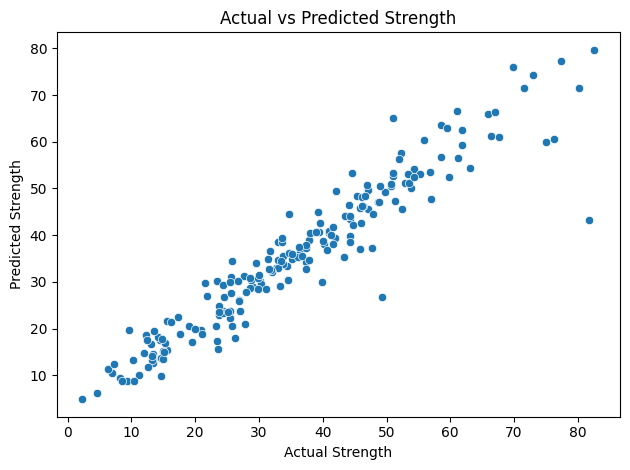

In [20]:
# Plot actual vs predicted values correctly
sns.scatterplot(x=y_test, y=y_final_pred)

# Add title and labels using plt correctly
plt.title('Actual vs Predicted Strength')
plt.xlabel('Actual Strength')
plt.ylabel('Predicted Strength')

plt.tight_layout()
plt.show()

In [21]:
def pred_strength(cement,slag,ash,water,superplastic,coarseagg,fineagg,age):
    features=np.array([[cement,slag,ash,water,superplastic,coarseagg,fineagg,age]])
    pred = best_model.predict(features).reshape(1,-1)

    return pred[0]

In [22]:
cement=349.0
slag=0.0
ash=0.0
water=192.0
superplastic=0.0
coarseagg=1047.0
fineagg=806.0
age=360

strength = pred_strength(cement,slag,ash,water,superplastic,coarseagg,fineagg,age)
print(strength)

[42.12955]


In [23]:
import flask
import joblib
import requests

In [24]:
joblib.dump(best_model,'conc_strength.joblib')

['conc_strength.joblib']

In [25]:
import os
print(os.getcwd())

C:\Users\GAGAN YADAV\Py_new\Projects\Capstone\Concrete Strength


In [26]:
print(os.path.exists('conc_strength.joblib'))

True


In [27]:
loaded_model=joblib.load('conc_strength.joblib')

In [28]:
sample=pd.DataFrame([{'cement':349.0,
'slag':0.0,
'ash':0.0,
'water':192.0,
'superplastic':0.0,
'coarseagg':1047.0,
'fineagg':806.0,
'age':360}])

prediction=loaded_model.predict(sample)
print(prediction)

[42.12955]


In [29]:
os.makedirs('templates', exist_ok=True)
print('Template folder created')

Template folder created


In [30]:
%%writefile templates/index.html
<!DOCTYPE html>
<html lang="en" class="dark">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Concrete Strength Intelligence Platform</title>
    <!-- Tailwind CSS CDN -->
    <script src="https://cdn.tailwindcss.com"></script>
    <!-- FontAwesome Icons -->
    <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.4.0/css/all.min.css">
    <!-- Google Fonts -->
    <link href="https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@300;400;500;600;700;800&display=swap" rel="stylesheet">
    <script>
        tailwind.config = {
            darkMode: 'class',
            theme: {
                extend: {
                    fontFamily: { sans: ['"Plus Jakarta Sans"', 'sans-serif'] },
                    colors: {
                        brand: { 500: '#3b82f6', 600: '#2563eb', 700: '#1d4ed8' },
                        emeraldBrand: { 500: '#10b981', 600: '#059669', 900: '#064e3b' }
                    }
                }
            }
        }
    </script>
    <style>
        .glass-card {
            background: rgba(30, 41, 59, 0.85);
            backdrop-filter: blur(14px);
            border: 1px solid rgba(255, 255, 255, 0.08);
        }
    </style>
</head>
<body class="bg-slate-950 text-slate-100 min-h-screen flex items-center justify-center p-4 md:p-8">

<div class="w-full max-w-4xl glass-card rounded-2xl shadow-2xl p-6 sm:p-10 relative overflow-hidden">
    <!-- Subtle Background Glow -->
    <div class="absolute -top-24 -right-24 w-72 h-72 bg-blue-500/10 rounded-full blur-3xl pointer-events-none"></div>
    <div class="absolute -bottom-24 -left-24 w-72 h-72 bg-emerald-500/10 rounded-full blur-3xl pointer-events-none"></div>

    <!-- Header Section -->
    <div class="text-center mb-8">
        <span class="inline-flex items-center gap-1.5 px-3 py-1 rounded-full text-xs font-semibold bg-emerald-950 text-emerald-400 border border-emerald-800/80 mb-3">
            <i class="fa-solid fa-microchip"></i> Machine Learning Production Predictor
        </span>
        <h1 class="text-2xl sm:text-3xl font-extrabold tracking-tight text-white">
            Concrete Strength Intelligence
        </h1>
        <p class="text-sm text-slate-400 mt-2 max-w-xl mx-auto">
            Input batch proportions and hydration curing age to forecast laboratory compressive strength (MPa).
        </p>
    </div>

    <!-- Quick Preset Buttons -->
    <div class="mb-6 bg-slate-900/60 p-3 rounded-xl border border-slate-800 flex flex-wrap items-center justify-between gap-2">
        <span class="text-xs font-semibold text-slate-400 flex items-center gap-1">
            <i class="fa-solid fa-bolt text-amber-400"></i> Load Test Mixes:
        </span>
        <div class="flex flex-wrap gap-2">
            <button type="button" onclick="loadPreset('standard')" class="px-2.5 py-1 text-xs rounded-lg bg-slate-800 hover:bg-slate-700 text-slate-300 transition border border-slate-700">Standard M25</button>
            <button type="button" onclick="loadPreset('high_strength')" class="px-2.5 py-1 text-xs rounded-lg bg-slate-800 hover:bg-slate-700 text-slate-300 transition border border-slate-700">High Strength M55</button>
            <button type="button" onclick="loadPreset('fly_ash')" class="px-2.5 py-1 text-xs rounded-lg bg-slate-800 hover:bg-slate-700 text-slate-300 transition border border-slate-700">High Fly-Ash Mix</button>
        </div>
    </div>

    <!-- Main Formulation Form -->
    <form action="/predict" method="POST" id="predictForm" class="space-y-6">
        <div class="grid grid-cols-1 sm:grid-cols-2 gap-4 sm:gap-5">
            
            <!-- Cement -->
            <div class="space-y-1.5">
                <div class="flex justify-between items-center text-xs">
                    <label for="cement" class="font-semibold text-slate-300 flex items-center gap-1.5">
                        <i class="fa-solid fa-cubes text-blue-400"></i> Cement
                    </label>
                    <span class="text-slate-500">kg/m³</span>
                </div>
                <input type="number" step="any" min="0" id="cement" name="cement" required placeholder="100 - 540"
                    class="w-full bg-slate-900 border border-slate-800 rounded-xl px-3.5 py-2.5 text-sm text-sky-400 focus:outline-none focus:border-blue-500 focus:ring-1 focus:ring-blue-500 transition">
            </div>

            <!-- Blast Furnace Slag -->
            <div class="space-y-1.5">
                <div class="flex justify-between items-center text-xs">
                    <label for="slag" class="font-semibold text-slate-300 flex items-center gap-1.5">
                        <i class="fa-solid fa-industry text-blue-400"></i> Blast Furnace Slag
                    </label>
                    <span class="text-slate-500">kg/m³</span>
                </div>
                <input type="number" step="any" min="0" id="slag" name="slag" required placeholder="0.0 - 360"
                    class="w-full bg-slate-900 border border-slate-800 rounded-xl px-3.5 py-2.5 text-sm text-sky-400 focus:outline-none focus:border-blue-500 focus:ring-1 focus:ring-blue-500 transition">
            </div>

            <!-- Fly Ash -->
            <div class="space-y-1.5">
                <div class="flex justify-between items-center text-xs">
                    <label for="ash" class="font-semibold text-slate-300 flex items-center gap-1.5">
                        <i class="fa-solid fa-smog text-blue-400"></i> Fly Ash
                    </label>
                    <span class="text-slate-500">kg/m³</span>
                </div>
                <input type="number" step="any" min="0" id="ash" name="ash" required placeholder="0.0 - 200"
                    class="w-full bg-slate-900 border border-slate-800 rounded-xl px-3.5 py-2.5 text-sm text-sky-400 focus:outline-none focus:border-blue-500 focus:ring-1 focus:ring-blue-500 transition">
            </div>

            <!-- Water -->
            <div class="space-y-1.5">
                <div class="flex justify-between items-center text-xs">
                    <label for="water" class="font-semibold text-slate-300 flex items-center gap-1.5">
                        <i class="fa-solid fa-droplet text-blue-400"></i> Water Content
                    </label>
                    <span class="text-slate-500">kg/m³</span>
                </div>
                <input type="number" step="any" min="0" id="water" name="water" required placeholder="120 - 250"
                    class="w-full bg-slate-900 border border-slate-800 rounded-xl px-3.5 py-2.5 text-sm text-sky-400 focus:outline-none focus:border-blue-500 focus:ring-1 focus:ring-blue-500 transition">
            </div>

            <!-- Superplasticizer -->
            <div class="space-y-1.5">
                <div class="flex justify-between items-center text-xs">
                    <label for="superplastic" class="font-semibold text-slate-300 flex items-center gap-1.5">
                        <i class="fa-solid fa-flask text-blue-400"></i> Superplasticizer
                    </label>
                    <span class="text-slate-500">kg/m³</span>
                </div>
                <input type="number" step="any" min="0" id="superplastic" name="superplastic" required placeholder="0.0 - 32"
                    class="w-full bg-slate-900 border border-slate-800 rounded-xl px-3.5 py-2.5 text-sm text-sky-400 focus:outline-none focus:border-blue-500 focus:ring-1 focus:ring-blue-500 transition">
            </div>

            <!-- Coarse Aggregate -->
            <div class="space-y-1.5">
                <div class="flex justify-between items-center text-xs">
                    <label for="coarseagg" class="font-semibold text-slate-300 flex items-center gap-1.5">
                        <i class="fa-solid fa-mountain text-blue-400"></i> Coarse Aggregate
                    </label>
                    <span class="text-slate-500">kg/m³</span>
                </div>
                <input type="number" step="any" min="0" id="coarseagg" name="coarseagg" required placeholder="800 - 1150"
                    class="w-full bg-slate-900 border border-slate-800 rounded-xl px-3.5 py-2.5 text-sm text-sky-400 focus:outline-none focus:border-blue-500 focus:ring-1 focus:ring-blue-500 transition">
            </div>

            <!-- Fine Aggregate -->
            <div class="space-y-1.5">
                <div class="flex justify-between items-center text-xs">
                    <label for="fineagg" class="font-semibold text-slate-300 flex items-center gap-1.5">
                        <i class="fa-solid fa-layer-group text-blue-400"></i> Fine Aggregate
                    </label>
                    <span class="text-slate-500">kg/m³</span>
                </div>
                <input type="number" step="any" min="0" id="fineagg" name="fineagg" required placeholder="590 - 990"
                    class="w-full bg-slate-900 border border-slate-800 rounded-xl px-3.5 py-2.5 text-sm text-sky-400 focus:outline-none focus:border-blue-500 focus:ring-1 focus:ring-blue-500 transition">
            </div>

            <!-- Age -->
            <div class="space-y-1.5">
                <div class="flex justify-between items-center text-xs">
                    <label for="age" class="font-semibold text-slate-300 flex items-center gap-1.5">
                        <i class="fa-solid fa-clock-rotate-left text-blue-400"></i> Curing Age
                    </label>
                    <span class="text-slate-500">Days</span>
                </div>
                <input type="number" step="any" min="1" max="365" id="age" name="age" required placeholder="1 - 365"
                    class="w-full bg-slate-900 border border-slate-800 rounded-xl px-3.5 py-2.5 text-sm text-sky-400 focus:outline-none focus:border-blue-500 focus:ring-1 focus:ring-blue-500 transition">
            </div>
        </div>

        <!-- Submit Button -->
        <button type="submit" id="submitBtn"
            class="w-full py-3.5 px-6 rounded-xl bg-gradient-to-r from-blue-600 to-indigo-600 hover:from-blue-500 hover:to-indigo-500 text-white font-bold text-sm shadow-lg shadow-blue-500/20 hover:shadow-blue-500/30 transition flex items-center justify-center gap-2">
            <span>Calculate Concrete Strength</span>
            <i class="fa-solid fa-arrow-right"></i>
        </button>
    </form>

    <!-- Prediction Output Card -->
    {% if strength %}
    <div id="resultContainer" class="mt-8 p-6 rounded-2xl bg-gradient-to-br from-emerald-950/80 to-slate-900 border border-emerald-600/40 shadow-xl">
        <div class="flex flex-col sm:flex-row justify-between items-start sm:items-center gap-4 border-b border-emerald-900/60 pb-4">
            <div>
                <span class="text-xs font-bold text-emerald-400 uppercase tracking-wider">Estimated Compressive Strength</span>
                <div class="flex items-baseline gap-2 mt-1">
                    <span class="text-4xl font-extrabold text-white tracking-tight">{{ strength }}</span>
                    <span class="text-lg font-semibold text-emerald-400">MPa</span>
                </div>
            </div>
            <div class="px-3.5 py-1.5 rounded-full text-xs font-semibold bg-emerald-900/60 border border-emerald-700 text-emerald-200">
                Grade: {% if strength < 20 %}Low Strength{% elif strength <= 40 %}Standard Construction (M20-M40){% else %}High Strength Concrete (>M40){% endif %}
            </div>
        </div>

        <!-- Secondary Calculated Properties -->
        <div class="grid grid-cols-2 sm:grid-cols-3 gap-3 pt-4 text-xs text-slate-400">
            <div>
                <span class="block text-slate-500">Water-to-Cement:</span>
                <span class="font-semibold text-slate-300" id="dispWcRatio">{{ wc_ratio or 'N/A' }}</span>
            </div>
            <div>
                <span class="block text-slate-500">Water-to-Binder:</span>
                <span class="font-semibold text-slate-300" id="dispWbRatio">{{ wb_ratio or 'N/A' }}</span>
            </div>
            <div>
                <span class="block text-slate-500">Curing Status:</span>
                <span class="font-semibold text-slate-300">Target Reached</span>
            </div>
        </div>
    </div>
    {% endif %}
</div>

<!-- Preset Loader Script -->
<script>
    const presets = {
        standard: { cement: 332.5, slag: 142.5, ash: 0.0, water: 228.0, superplastic: 0.0, coarseagg: 932.0, fineagg: 594.0, age: 28 },
        high_strength: { cement: 540.0, slag: 0.0, ash: 0.0, water: 162.0, superplastic: 2.5, coarseagg: 1040.0, fineagg: 676.0, age: 28 },
        fly_ash: { cement: 260.9, slag: 100.5, ash: 78.3, water: 200.6, superplastic: 8.6, coarseagg: 864.5, fineagg: 761.5, age: 28 }
    };

    function loadPreset(key) {
        const data = presets[key];
        for (const [field, val] of Object.entries(data)) {
            const input = document.getElementById(field);
            if (input) input.value = val;
        }
    }
</script>

</body>
</html>

Overwriting templates/index.html


In [31]:
%%writefile app.py

from flask import Flask, render_template, request
import joblib
import pandas as pd

app = Flask(__name__)

# Load trained model/pipeline
model = joblib.load('conc_strength.joblib')


@app.route('/')
def home():
  return render_template('index.html')


@app.route('/predict', methods=['POST'])
def predict():
  cement = float(request.form['cement'])
  slag = float(request.form['slag'])
  ash = float(request.form['ash'])
  water = float(request.form['water'])
  superplastic = float(request.form['superplastic'])
  coarseagg = float(request.form['coarseagg'])
  fineagg = float(request.form['fineagg'])
  age = float(request.form['age'])

  features = {
      'cement': cement,
      'slag': slag,
      'ash': ash,
      'water': water,
      'superplastic': superplastic,
      'coarseagg': coarseagg,
      'fineagg': fineagg,
      'age': age,
  }

  input_df = pd.DataFrame([features])
  prediction = model.predict(input_df)[0]

  # Compute domain ratios
  wc_ratio = round(water / cement, 2) if cement > 0 else 'N/A'
  total_binder = cement + slag + ash
  wb_ratio = round(water / total_binder, 2) if total_binder > 0 else 'N/A'

  return render_template(
      'index.html',
      strength=round(prediction, 2),
      wc_ratio=wc_ratio,
      wb_ratio=wb_ratio,
  )


if __name__ == '__main__':
    app.run(host='0.0.0.0',
           port=5000,
           debug=False)

Overwriting app.py


In [32]:
%%writefile requirements.txt
Flask==3.1.2
numpy
scikit-learn
joblib

Overwriting requirements.txt


In [33]:
import os

required_files= ['app.py',
                'conc_strength.joblib',
                'requirements.txt',
                os.path.join('templates','index.html')]

for file_name in required_files:
    if os.path.exists(file_name):
        print('Found:', file_name)
    else:
        print('Not Found:', file_name)

Found: app.py
Found: conc_strength.joblib
Found: requirements.txt
Found: templates\index.html


In [34]:
import zipfile

zip_file_name='conc_strength_ec2.zip'

with zipfile.ZipFile(zip_file_name,'w', zipfile.ZIP_DEFLATED) as zip_file:
    zip_file.write('app.py')
    zip_file.write('conc_strength.joblib')
    zip_file.write('requirements.txt')
    zip_file.write(os.path.join('templates', 'index.html'),
                  arcname=os.path.join('templates', 'index.html'))
print('Deployment ZIP created:', zip_file_name)
print('Full location:', os.path.abspath(zip_file_name))

Deployment ZIP created: conc_strength_ec2.zip
Full location: C:\Users\GAGAN YADAV\Py_new\Projects\Capstone\Concrete Strength\conc_strength_ec2.zip


### Report on Challenges Faced

* **Missing Values**: Missing values were checked before building the model.
* **Duplicate Data**: Duplicate records were checked and removed to avoid repeated observations.
* **Outliers**: Boxplots and the IQR method were used to identify possible outliers. They were not removed automatically because they may represent valid concrete measurements.
* **Different Scales**: StandardScaler was used for models where feature scaling is required.
* **Nonlinear Relationships**: Different machine learning models were tested because concrete strength has a nonlinear relationship with its ingredients and age.
* **Model Selection**: Several models were compared using R², MAE and RMSE. Cross-validation was also used to select a suitable model.
* **Hyperparameter Tuning**: GridSearchCV was used to find better model parameters and improve model performance.

## Conclusion

* The concrete dataset was analyzed and cleaned before machine learning.
* Different regression models were trained and compared using R², MAE and RMSE.
* The best-performing model was selected for predicting concrete compressive strength.
* The final model can predict concrete strength using the concrete ingredients and age of the concrete.